# 0. Import Datasets and Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
import os
from tqdm import tqdm
import warnings
import lightgbm as lgb
from sklearn.metrics import mean_squared_log_error

warnings.filterwarnings("ignore")

/usr/local/lib/python3.12/dist-packages/sqlalchemy/orm/query.py:195: SyntaxWarning: "is not" with 'tuple' literal. Did you mean "!="?
  if entities is not ():


In [2]:
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/store-sales-time-series-forecasting/oil.csv
/kaggle/input/store-sales-time-series-forecasting/sample_submission.csv
/kaggle/input/store-sales-time-series-forecasting/holidays_events.csv
/kaggle/input/store-sales-time-series-forecasting/stores.csv
/kaggle/input/store-sales-time-series-forecasting/train.csv
/kaggle/input/store-sales-time-series-forecasting/test.csv
/kaggle/input/store-sales-time-series-forecasting/transactions.csv


In [3]:
train=pd.read_csv(r"/kaggle/input/store-sales-time-series-forecasting/train.csv",parse_dates=["date"])
test=pd.read_csv(r"/kaggle/input/store-sales-time-series-forecasting/test.csv",parse_dates=["date"])
sub=pd.read_csv(r"/kaggle/input/store-sales-time-series-forecasting/sample_submission.csv")
oil=pd.read_csv(r"/kaggle/input/store-sales-time-series-forecasting/oil.csv",parse_dates=["date"])
stores=pd.read_csv(r"/kaggle/input/store-sales-time-series-forecasting/stores.csv")
holidays=pd.read_csv(r"/kaggle/input/store-sales-time-series-forecasting/holidays_events.csv",parse_dates=["date"])
txns=pd.read_csv(r"/kaggle/input/store-sales-time-series-forecasting/transactions.csv",parse_dates=["date"])

In [4]:
stores.rename(columns={'type': 'store_type'}, inplace=True)
holidays.rename(columns={'type': 'holiday_type'}, inplace=True)

In [5]:
all_df = {
    'train': train,
    'test': test,
    'oil': oil,
    'stores': stores,
    'holidays': holidays,
    'txns': txns
}

for name, df in all_df.items():
    print('#########')
    print(f"{name} shape:",df.shape)
    print(f"{name} info:")
    df.info()
    print("\n\n")

for name, df in all_df.items():
    print('##########')
    print(f"{name}:")
    display(df.head())


#########
train shape: (3000888, 6)
train info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype         
---  ------       -----         
 0   id           int64         
 1   date         datetime64[ns]
 2   store_nbr    int64         
 3   family       object        
 4   sales        float64       
 5   onpromotion  int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 137.4+ MB



#########
test shape: (28512, 5)
test info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28512 entries, 0 to 28511
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   id           28512 non-null  int64         
 1   date         28512 non-null  datetime64[ns]
 2   store_nbr    28512 non-null  int64         
 3   family       28512 non-null  object        
 4   onpromotion  28512 non-null  int64     

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


##########
test:


,id,date,store_nbr,family,onpromotion
0,3000888,2017-08-16,1,AUTOMOTIVE,0
1,3000889,2017-08-16,1,BABY CARE,0
2,3000890,2017-08-16,1,BEAUTY,2
3,3000891,2017-08-16,1,BEVERAGES,20
4,3000892,2017-08-16,1,BOOKS,0


##########
oil:


...

,store_nbr,city,state,store_type,cluster
0,1,Quito,Pichincha,D,13
1,2,Quito,Pichincha,D,13
2,3,Quito,Pichincha,D,8
3,4,Quito,Pichincha,D,9
4,5,Santo Domingo,Santo Domingo de los Tsachilas,D,4


##########
holidays:


,date,holiday_type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False


##########
txns:


,date,store_nbr,transactions
0,2013-01-01,25,770
1,2013-01-02,1,2111
2,2013-01-02,2,2358
3,2013-01-02,3,3487
4,2013-01-02,4,1922


In [6]:
for name, df in all_df.items():
    print('##########')
    print(f"{name}:")
    display(df.head())

##########
train:


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


##########
test:


,id,date,store_nbr,family,onpromotion
0,3000888,2017-08-16,1,AUTOMOTIVE,0
1,3000889,2017-08-16,1,BABY CARE,0
2,3000890,2017-08-16,1,BEAUTY,2
3,3000891,2017-08-16,1,BEVERAGES,20
4,3000892,2017-08-16,1,BOOKS,0


##########
oil:


...

,store_nbr,city,state,store_type,cluster
0,1,Quito,Pichincha,D,13
1,2,Quito,Pichincha,D,13
2,3,Quito,Pichincha,D,8
3,4,Quito,Pichincha,D,9
4,5,Santo Domingo,Santo Domingo de los Tsachilas,D,4


##########
holidays:


,date,holiday_type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False


##########
txns:


,date,store_nbr,transactions
0,2013-01-01,25,770
1,2013-01-02,1,2111
2,2013-01-02,2,2358
3,2013-01-02,3,3487
4,2013-01-02,4,1922


# 1. Handle Pre-Opening Gap
- **Finding**: Many stores (e.g., Store 52) and specific product families have long streaks of 0 sales at the start of train.csv.
- **Action**: I have implemented a filter to remove rows before the first non-zero sale for every store_nbr + family combination. This prevents the model from learning "fake" zero patterns.

In [7]:
def remove_pre_opening_data(df):
    """
    Finds the first non-zero sales date for each (store, family) pair
    and removes all preceding rows.
    """
    # 1. Sort by store, family, and date to ensure time continuity
    df = df.sort_values(['store_nbr', 'family', 'date'])

    # 2. Create a boolean mask where sales are > 0
    # This identifies the "active" selling moments
    has_sales = df['sales'] > 0

    # 3. Use groupby + cumsum to flag all rows after the first non-zero sale
    # Any row where 'active_flag' > 0 is either the first sale or a subsequent date
    df['active_flag'] = has_sales.groupby([df['store_nbr'], df['family']]).cumsum()

    # 4. Filter to keep only active rows
    # We use > 0 so that if a store has 0 sales AFTER opening, it stays in the data.
    filtered_df = df[df['active_flag'] > 0].copy()

    # 5. Cleanup the helper column
    filtered_df = filtered_df.drop(columns=['active_flag'])
    
    return filtered_df

# Usage
train = remove_pre_opening_data(train)

# 2. Add Time Features
Wages & Paydays:

Pattern: Public sector wages are paid on the 15th and last day of the month.

Feature: Added is_public_payday to capture the bi-weekly spending surges.

In [8]:
def add_time_features(df, date_col='date'):
    """
    Extracts time-series features from a date column.
    """
    # 1. Basic components
    df['year'] = df[date_col].dt.year
    df['month'] = df[date_col].dt.month
    df['day'] = df[date_col].dt.day
    
    # 2. Week-based features
    # weekday: Monday=1, Sunday=7
    df['day_of_week'] = df[date_col].dt.dayofweek + 1
    df['is_weekend'] = df['day_of_week'].isin([6, 7]).astype(int)
    
    # 3. Seasonal features
    # df['day_of_year'] = df[date_col].dt.dayofyear
    # df['week_of_year'] = df[date_col].dt.isocalendar().week.astype(int)
    df['quarter'] = df[date_col].dt.quarter
    
    # 4. Exact Paydays
    df['is_public_payday'] = (
        (df[date_col].dt.day == 15) | 
        (df[date_col].dt.is_month_end)
    ).astype(int)
    
    return df

# Usage:
train = add_time_features(train)
test = add_time_features(test)

In [9]:
def create_cyclic_encoding(df, name):
    all_cols = df.columns.tolist()
    print(all_cols)

    if 'month' in all_cols:
        # Cyclic Month (max is 12)
        df['month_sin'] = np.sin(2 * np.pi * df['month'].astype("int8") / 12)
        df['month_cos'] = np.cos(2 * np.pi * df['month'].astype("int8") / 12)

    if 'day' in all_cols:
        # Cyclic Day of Month (max is 31)
        df['day_sin'] = np.sin(2 * np.pi * df['day'].astype("int8") / 31)
        df['day_cos'] = np.cos(2 * np.pi * df['day'].astype("int8") / 31)

    if 'day_of_week' in all_cols:
        # Cyclic Day of Week (max is 7)
        df['dow_sin'] = np.sin(2 * np.pi * df['day_of_week'].astype("int8") / 7)
        df['dow_cos'] = np.cos(2 * np.pi * df['day_of_week'].astype("int8") / 7)

    if 'quarter' in all_cols:
        # Cyclic Quarter (max is 4)
        df['quarter_sin'] = np.sin(2 * np.pi * df['quarter'].astype("int8") / 4)
        df['quarter_cos'] = np.cos(2 * np.pi * df['quarter'].astype("int8") / 4)

    print(f'Added cyclic encoded time features in {name} Dataset\n\n')
    return df

train = create_cyclic_encoding(train, 'Train')
test = create_cyclic_encoding(test, 'Test')

['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion', 'year', 'month', 'day', 'day_of_week', 'is_weekend', 'quarter', 'is_public_payday']
Added cyclic encoded time features in Train Dataset


['id', 'date', 'store_nbr', 'family', 'onpromotion', 'year', 'month', 'day', 'day_of_week', 'is_weekend', 'quarter', 'is_public_payday']
Added cyclic encoded time features in Test Dataset




# 3. Add Oil Price (Economic Health):

Behavior: Ecuador is oil-dependent. Prices are missing on weekends and holidays.

Preprocessing: I’ve merged oil prices and used `pd.NA` to handle weekend gaps. This preserves the "Truth" of the market as it tells the model: "There was no trading activity today." Tree-based models like LightGBM can actually learn that a "Missing" value is a feature in itself (e.g., "It's a weekend").

Alternatives
- Forward Fill (ffill): This is the most common retail strategy. It assumes the last known price is the current value until the market reopens.
- Moving Average: This smooths out daily volatility, providing the model with a "trend" rather than a jittery daily price.

In [10]:
# def add_oil_price(df, oil):
#     df= df.merge(oil, how='left', on='date')
#     df = df.rename(columns={'dcoilwtico': 'daily_oil_price'})
#     return df

# train = add_oil_price(train, oil)
# test = add_oil_price(test, oil)

In [11]:
def add_oil_price_ffill(df, oil):
    # Sort oil data by date to ensure correct time order
    oil_sorted = oil.sort_values("date").copy()

    # Forward fill: use Friday's price for Saturday/Sunday, etc.
    oil_sorted["dcoilwtico"] = oil_sorted["dcoilwtico"].fillna(method="ffill")

    # Merge and rename column
    df = df.merge(oil_sorted, how="left", on="date")
    df = df.rename(columns={"dcoilwtico": "daily_oil_price"})
    return df

train = add_oil_price_ffill(train, oil)
test  = add_oil_price_ffill(test, oil)


# 4. Add Store Details

In [12]:
def add_store_details(df, stores):
    len_b4 = len(df) 
    df= df.merge(stores, how='inner', on='store_nbr')
    df = df.rename(columns={'city': 'store_city', 'state': 'store_state', 'cluster': 'store_cluster'})
    len_after = len(df) 

    print('Num of instances before merging: ', len_b4)
    print('Num of instances after merging: ', len_after)
    print('\n\n')
    
    return df

train = add_store_details(train, stores)
test = add_store_details(test, stores)

Num of instances before merging:  2444680
Num of instances after merging:  2444680



Num of instances before merging:  28512
Num of instances after merging:  28512





# 5. Transactions

In [13]:
# Add transaction details
def add_transactions_features(df, txns):
    # txns has: date, store_nbr, transactions
    out = df.merge(txns, on=["date", "store_nbr"], how="left")

    # transactions can be missing for some dates/stores → safe fill
    out["transactions"] = out["transactions"].fillna(0)

    # log transactions
    out["log_transactions"] = np.log1p(out["transactions"])
    return out

train = add_transactions_features(train, txns)
test  = add_transactions_features(test, txns)


In [14]:
# Add transaction rolling
def add_transactions_rolling_features(df):
    df = df.sort_values(["store_nbr", "date"])

    df["transactions_rolling_7"] = (
        df.groupby("store_nbr")["transactions"].shift(1).rolling(window=7).mean()
    )

    # Fill early Nans safely
    df["transactions_rolling_7"] = df["transactions_rolling_7"].fillna(0)

    return df

train = add_transactions_rolling_features(train)
test = add_transactions_rolling_features(test)

# 6. Sales Lag

In [15]:
# Add sales lag
def add_sales_lag_7(train, test):
    train = train.copy()
    test = test.copy()

    train["_is_train"] = 1
    test["_is_train"] = 0

    df_all = pd.concat([train, test], axis=0, ignore_index=True, sort=False)
    df_all = df_all.sort_values(["store_nbr", "family", "date"])

    df_all["sales_lag_7"] = (
        df_all.groupby(["store_nbr", "family"])["sales"]
              .shift(7)
    )

    df_all["sales_lag_7"] = df_all["sales_lag_7"].fillna(0)

    # split back safely
    train_out = df_all[df_all["_is_train"] == 1].drop(columns=["_is_train"])
    test_out  = df_all[df_all["_is_train"] == 0].drop(columns=["_is_train"])

    # cleanup helper columns if present
    if "sales" in test_out.columns:
        pass  

    return train_out, test_out


train, test = add_sales_lag_7(train, test)

# 7. Geographic-Hierarchical Holiday Mapping
Behavior
- The Ecuadorian holiday calendar is complex because it operates on three distinct geographic levels (National, Regional, and Local) and includes administrative changes like transfers and payback days. Specifically:
  - Transfers: If a holiday is moved to a different date (`transferred=True`), the original calendar date becomes a "Ghost Day" (regular workday), and the new date becomes the "celebrated" holiday.
  - Bridge Paybacks (`holiday_type=='Work Day'`): These are Saturdays where citizens work to "pay back" an extra day off granted during a long weekend.
  - Hierarchy: Multiple holidays can overlap on the same day (e.g., a city holiday falling on a national holiday).

Preprocessing
To accurately capture the impact on sales, the function performs a hierarchical multi-level merge:
- Status Tagging: It identifies "Ghost Days" by labeling them as 'Transferred Away' and renames work-day substitutes to 'Bridge Payback'.
- Tiered Merging: It joins the holiday data to the sales data three times using different keys:
  - National: Joined by date only (affects all stores).
  - Regional: Joined by date and store_state.
  - Local: Joined by date and store_city.
- Conflict Resolution: It uses `.combine_first()` to prioritize the impact scale: National > Regional > Local. If a store has both a local and national holiday, the national metadata takes precedence.
- Logical Flagging: It creates a binary `is_holiday` column that is only True for actual celebrated days. It excludes `Transferred Away` and `Bridge Payback` days because consumer behavior on those days typically resembles a normal workday.

In [16]:
def add_holiday_features_full(df, holidays):
    """
    df: Training/Test dataframe (must contain store_city and store_state)
    holidays: The holiday_events dataframe
    """
    columns_to_keep = df.columns.tolist()
    hols = holidays.copy()

    # Rename for safety
    hols = hols.rename(columns={'holiday_type': 'h_type'})

    # 1. Handle Transfers (Ghost Days)
    hols.loc[hols['transferred'] == True, 'h_type'] = 'Transferred Away'

    # 2. Rename Payback Days
    hols['h_type'] = hols['h_type'].replace('Work Day', 'Bridge Payback')

    # Helper: celebrated holiday mask
    hols['is_celebrated'] = (
        hols['h_type'].notna() &
        (~hols['h_type'].isin(['Transferred Away', 'Bridge Payback']))
    )

    # 3. Split by Locale
    nat = hols[hols['locale'] == 'National']
    reg = hols[hols['locale'] == 'Regional']
    loc = hols[hols['locale'] == 'Local']

    # --- MERGE NATIONAL ---
    df = df.merge(
        nat[['date', 'h_type', 'is_celebrated']],
        on='date',
        how='left'
    )

    df = df.rename(columns={
        'h_type': 'h_type_nat',
        'is_celebrated': 'is_national_holiday'
    })

    # --- MERGE REGIONAL ---
    df = df.merge(
        reg[['date', 'locale_name', 'h_type', 'is_celebrated']],
        left_on=['date', 'store_state'],
        right_on=['date', 'locale_name'],
        how='left',
        suffixes=('', '_reg')
    )

    df = df.rename(columns={
        'h_type': 'h_type_reg',
        'is_celebrated': 'is_regional_holiday'
    })

    # --- MERGE LOCAL ---
    df = df.merge(
        loc[['date', 'locale_name', 'h_type', 'is_celebrated']],
        left_on=['date', 'store_city'],
        right_on=['date', 'locale_name'],
        how='left',
        suffixes=('', '_loc')
    )

    df = df.rename(columns={
        'h_type': 'h_type_loc',
        'is_celebrated': 'is_local_holiday'
    })

    df = df.fillna(value={'is_national_holiday': False, 'is_regional_holiday': False, 'is_local_holiday': False})

    # 6. Keep required columns
    columns_to_keep.extend([
        'h_type_nat',
        'h_type_reg',
        'h_type_loc',
        'is_national_holiday',
        'is_regional_holiday',
        'is_local_holiday'
    ])

    df = df[columns_to_keep]

    return df

train = add_holiday_features_full(train, holidays)
test = add_holiday_features_full(test, holidays)

In [17]:
# -----------------------------------------------------------------------------
# NEW CELL: Fill Missing Holiday Values
# Location: Insert this AFTER Cell 15 and BEFORE Cell 16
# -----------------------------------------------------------------------------

# Define the columns that were just created in the previous step
holiday_string_cols = ['h_type_nat', 'h_type_reg', 'h_type_loc']

# Fill NaNs with "No_Holiday" for both Train and Test sets
# This ensures that when we convert to 'category' later, "No_Holiday" is a valid class.
for col in holiday_string_cols:
    train[col] = train[col].fillna("No_Holiday")
    test[col] = test[col].fillna("No_Holiday")

print("Success: Filled NaN values in holiday columns with 'No_Holiday'.")

Success: Filled NaN values in holiday columns with 'No_Holiday'.


# 8. Handle feature dtype

In [18]:
id = 'id'
timestamp = ['date']
target = ['sales']

CATEGORICAL = [
    ### train & test
    'store_nbr',
    'family',
    ### store
    'store_city',
    'store_state',
    'store_type',
    'store_cluster', 
    ### holiday
    'h_type_nat',
    'h_type_reg',
    'h_type_loc',
    # 'description',
]

BOOLEAN = [
    ### time related
    'is_weekend',
    'is_public_payday',
    ### holiday
    'is_national_holiday',
    'is_regional_holiday',
    'is_local_holiday'    
]

NUMERICAL = [
    ### train & test
    'onpromotion',
    ### time related
    'year',
    'month_sin',
    'month_cos',
    'day_sin',
    'day_cos',
    'dow_sin',
    'dow_cos',
    'quarter_sin',
    'quarter_cos',
    ### oil
    'daily_oil_price',
    ### transactions
    # 'transactions',
    # 'log_transactions',
    # 'transactions_rolling_7',
    ### lag r
    # 'sales_lag_7',
]

FEATURES = CATEGORICAL + BOOLEAN + NUMERICAL

In [19]:
def prepare_dtypes(df):
    df = df.copy()

    # Datetime
    df[timestamp[0]] = pd.to_datetime(df[timestamp[0]])

    # Categorical
    for col in CATEGORICAL:
        df[col] = df[col].astype("category")

    # Boolean → int (LightGBM friendly)
    for col in BOOLEAN:
        df[col] = df[col].astype("int8")

    # Numerical
    for col in NUMERICAL:
        df[col] = df[col].astype("float32")

    return df

train = prepare_dtypes(train)
test = prepare_dtypes(test)

In [20]:
def set_ordered_categories(df, category_mappings):
    """
    Applies ordered categorical types to specific columns in a dataframe.
    
    Args:
        df (pd.DataFrame): The dataframe to modify.
        category_mappings (dict): A dictionary where keys are column names 
                                  and values are lists defining the order.
    """
    df = df.copy()
    
    for col, order in category_mappings.items():
        if col in df.columns:
            # Ensure the column is treated as a category first
            df[col] = pd.Categorical(df[col], categories=order, ordered=True)
            print(f"Fixed ordering for: {col}")
            
    return df

# 1. Define your specific business orders
orders = {
    'store_nbr': list(range(1, 55)),
    'store_type': ['A', 'B', 'C', 'D', 'E'],
    'store_cluster': list(range(1, 18)),
    'month': list(range(1, 13)),
    'day': list(range(1, 32)),
    'day_of_week': list(range(1, 8)),
    'quarter': [1, 2, 3, 4]
}

# 2. Apply the function
# train = set_ordered_categories(train, orders)
# test = set_ordered_categories(test, orders)

In [21]:
def prepare_dtypes(df):
    df = df.copy()

    # Datetime
    df[timestamp[0]] = pd.to_datetime(df[timestamp[0]])

    # Categorical
    for col in CATEGORICAL:
        df[col] = df[col].astype("category")

    # Boolean → int (LightGBM friendly)
    for col in BOOLEAN:
        df[col] = df[col].astype("int8")

    # Numerical
    for col in NUMERICAL:
        df[col] = df[col].astype("float32")

    return df

train = prepare_dtypes(train)
test = prepare_dtypes(test)

# 9. Final Check at Datasets

In [22]:
import matplotlib.pyplot as plt

def univariate_analysis(df: pd.DataFrame, visualize: bool = False):
    """
    Perform univariate EDA with support for numerical, categorical, boolean,
    and datetime features. Optional visualization.
    """

    def evaluate_numerical_feature(series: pd.Series, col_name: str):
        desc = series.describe()

        stats = {
            "dtype": series.dtype,
            "count": desc["count"],
            "null_count": series.isna().sum(),
            "mean": desc["mean"],
            "std": desc["std"],
            "min": desc["min"],
            "25%": desc["25%"],
            "50% (median)": desc["50%"],
            "75%": desc["75%"],
            "max": desc["max"]
        }

        if visualize:
            fig, axes = plt.subplots(1, 2, figsize=(10, 4))
            series.plot(kind="hist", bins=30, ax=axes[0], title=f"{col_name} - Histogram")
            series.plot(kind="box", ax=axes[1], title=f"{col_name} - Boxplot")
            plt.tight_layout()
            plt.show()

        return stats

    def evaluate_categorical_feature(series: pd.Series, col_name: str):
        stats = {
            "dtype": series.dtype,
            "count": series.count(),
            "null_count": series.isna().sum(),
            "n_unique": series.nunique(dropna=True),
            "value_distribution": series.value_counts(dropna=False, normalize=True).to_dict()
        }

        if visualize:
            series.value_counts(dropna=False).plot(
                kind="bar", figsize=(6, 4), title=f"{col_name} - Distribution"
            )
            plt.ylabel("Count")
            plt.show()

        return stats

    def evaluate_datetime_feature(series: pd.Series, col_name: str):
        series = pd.to_datetime(series)

        stats = {
            "dtype": series.dtype,
            "count": series.count(),
            "null_count": series.isna().sum(),
            "start_date": series.min(),
            "end_date": series.max(),
            "n_unique_dates": series.nunique(),
            "duplicate_dates": series.duplicated().sum()
        }

        # Missing dates detection (only if frequency can be inferred)
        try:
            full_range = pd.date_range(series.min(), series.max(), freq=pd.infer_freq(series.dropna()))
            stats["missing_dates"] = len(full_range.difference(series.dropna()))
        except Exception:
            stats["missing_dates"] = "Cannot infer frequency"

        if visualize:
            series.value_counts().sort_index().plot(
                figsize=(10, 4), title=f"{col_name} - Date Distribution"
            )
            plt.ylabel("Count")
            plt.show()

        return stats

    num_results = {}
    cat_results = {}
    date_results = {}
    unsupported_results = {}

    for col in df.columns:
        series = df[col]

        if (
            col in NUMERICAL
            or col in target
        ):
            num_results[col] = evaluate_numerical_feature(series, col)

        elif col in timestamp:
            date_results[col] = evaluate_datetime_feature(series, col)

        elif (
            col in BOOLEAN
            or col in CATEGORICAL
            or col is id
        ):
            cat_results[col] = evaluate_categorical_feature(series, col)

        else:
            unsupported_results[col] = {
                "dtype": series.dtype,
                "null_count": series.isna().sum(),
                "note": "Unsupported data type"
            }

    num_results = pd.DataFrame(num_results).T
    cat_results = pd.DataFrame(cat_results).T
    date_results = pd.DataFrame(date_results).T
    unsupported_results = pd.DataFrame(unsupported_results).T
    results = {
        'num': num_results,
        'cat': cat_results,
        'date': date_results,
        'unsupported': unsupported_results
    }
    return results

In [23]:
results = univariate_analysis(train, visualize=False)
for name, result in results.items():
    print(f'# {name} #')
    display(result)

# num #


,dtype,count,null_count,mean,std,min,25%,50% (median),75%,max
sales,float64,2451369.0,0,439.656108,1207.697658,0.0,3.0,32.0,287.67,124717.0
onpromotion,float32,2451369.0,0,3.202624,13.463262,0.0,0.0,0.0,1.0,741.0
year,float32,2451369.0,0,2015.063843,25.200319,2013.0,2014.0,2015.0,2016.0,2017.0
month_sin,float32,2451369.0,0,0.044104,0.701469,-1.0,-0.5,0.0,0.866025,1.0
month_cos,float32,2451369.0,0,-0.050271,0.707728,-1.0,-0.866025,-0.0,0.5,1.0
day_sin,float32,2451369.0,0,0.010412,0.714208,-0.998717,-0.724793,-0.0,0.724793,0.998717
day_cos,float32,2451369.0,0,-0.019126,0.700274,-0.994869,-0.758758,-0.050649,0.688967,1.0
dow_sin,float32,2451369.0,0,-0.000362,0.710826,-0.974928,-0.781832,-0.0,0.781832,0.974928
dow_cos,float32,2451369.0,0,0.002478,0.706895,-0.900969,-0.900969,-0.222521,0.62349,1.0
quarter_sin,float32,2451369.0,0,0.016561,0.713969,-1.0,-0.0,0.0,1.0,1.0


# cat #


,dtype,count,null_count,n_unique,value_distribution
store_nbr,category,2451369,0,54,"{34: 0.020364131226265812, 39: 0.0203559725198..."
family,category,2451369,0,33,"{'BEVERAGES': 0.034438715672752654, 'GROCERY I..."
is_weekend,int8,2451369,0,2,"{0: 0.7128469846848843, 1: 0.2871530153151158}"
is_public_payday,int8,2451369,0,2,"{0: 0.9341592391843089, 1: 0.06584076081569115}"
store_city,category,2451369,0,22,"{'Quito': 0.35320875804499446, 'Guayaquil': 0...."
store_state,category,2451369,0,16,"{'Pichincha': 0.3735365830276878, 'Guayas': 0...."
store_type,category,2451369,0,5,"{'D': 0.3445136166770486, 'C': 0.2813664527861..."
store_cluster,category,2451369,0,17,"{3: 0.1346831097235871, 10: 0.1088865038270452..."
h_type_nat,category,2451369,0,8,"{'No_Holiday': 0.910351725913153, 'Event': 0.0..."
h_type_reg,category,2451369,0,2,"{'No_Holiday': 0.9996589660716114, 'Holiday': ..."


# date #


,dtype,count,null_count,start_date,end_date,n_unique_dates,duplicate_dates,missing_dates
date,datetime64[ns],2451369,0,2013-01-01 00:00:00,2017-08-15 00:00:00,1684,2449685,4


# unsupported #


,dtype,null_count,note
id,int64,0,Unsupported data type
month,int32,0,Unsupported data type
day,int32,0,Unsupported data type
day_of_week,int32,0,Unsupported data type
quarter,int32,0,Unsupported data type
transactions,float64,0,Unsupported data type
log_transactions,float64,0,Unsupported data type
transactions_rolling_7,float64,0,Unsupported data type
sales_lag_7,float64,0,Unsupported data type


In [24]:
results = univariate_analysis(test, visualize=False)
for name, result in results.items():
    print(f'# {name} #')
    display(result)

# num #


,dtype,count,null_count,mean,std,min,25%,50% (median),75%,max
sales,float64,0.0,28512,NaN,NaN,NaN,NaN,NaN,NaN,NaN
onpromotion,float32,28512.0,0,6.965383,20.685951,0.0,0.0,0.0,6.0,646.0
year,float32,28512.0,0,2017.0,0.708341,2017.0,2017.0,2017.0,2017.0,2017.0
month_sin,float32,28512.0,0,-0.866025,0.000181,-0.866025,-0.866025,-0.866025,-0.866025,-0.866025
month_cos,float32,28512.0,0,-0.5,0.0,-0.5,-0.5,-0.5,-0.5,-0.5
day_sin,float32,28512.0,0,-0.616197,0.323537,-0.998717,-0.907791,-0.688083,-0.370608,-0.0
day_cos,float32,28512.0,0,0.03125,0.717419,-0.994869,-0.648769,0.050389,0.721916,1.0
dow_sin,float32,28512.0,0,0.0,0.679045,-0.974928,-0.520871,-0.0,0.520871,0.974928
dow_cos,float32,28512.0,0,-0.112621,0.72543,-0.900969,-0.900969,-0.222521,0.62349,1.0
quarter_sin,float32,28512.0,0,-1.0,0.0,-1.0,-1.0,-1.0,-1.0,-1.0


# cat #


,dtype,count,null_count,n_unique,value_distribution
store_nbr,category,28512,0,54,"{1: 0.018518518518518517, 2: 0.018518518518518..."
family,category,28512,0,33,"{'AUTOMOTIVE': 0.030303030303030304, 'BABY CAR..."
is_weekend,int8,28512,0,2,"{0: 0.75, 1: 0.25}"
is_public_payday,int8,28512,0,2,"{0: 0.9375, 1: 0.0625}"
store_city,category,28512,0,22,"{'Quito': 0.3333333333333333, 'Guayaquil': 0.1..."
store_state,category,28512,0,16,"{'Pichincha': 0.35185185185185186, 'Guayas': 0..."
store_type,category,28512,0,5,"{'D': 0.3333333333333333, 'C': 0.2777777777777..."
store_cluster,category,28512,0,17,"{3: 0.12962962962962962, 10: 0.111111111111111..."
h_type_nat,category,28512,0,1,{'No_Holiday': 1.0}
h_type_reg,category,28512,0,1,{'No_Holiday': 1.0}


# date #


,dtype,count,null_count,start_date,end_date,n_unique_dates,duplicate_dates,missing_dates
date,datetime64[ns],28512,0,2017-08-16 00:00:00,2017-08-31 00:00:00,16,28496,0


# unsupported #


,dtype,null_count,note
id,int64,0,Unsupported data type
month,int32,0,Unsupported data type
day,int32,0,Unsupported data type
day_of_week,int32,0,Unsupported data type
quarter,int32,0,Unsupported data type
transactions,float64,0,Unsupported data type
log_transactions,float64,0,Unsupported data type
transactions_rolling_7,float64,0,Unsupported data type
sales_lag_7,float64,0,Unsupported data type


# 10. Time-Based Split for Training (80%) and Testing (20%)

In [25]:
# 1. Identify the date threshold for the 80th percentile
# We use the unique dates present in the cleaned training set
dates = train['date'].copy()
dates.sort_values(ascending=True, inplace=True)

# Find the date that sits at the 80% mark of the timeline
split_date = dates.quantile(0.8)

print(f"80% Split Date: {split_date.date()}")

# 2. Perform the Split
# Everything up to (and including) the split_date is Training
# Everything after is Validation
X_train = train[train['date'] <= split_date].drop(columns=target)
y_train = train[train['date'] <= split_date][target]

X_val = train[train['date'] > split_date].drop(columns=target)
y_val = train[train['date'] > split_date][target]

# 3. Verify the split proportions
print(f"Training observations: {len(X_train)} ({len(X_train)/len(train)*100:.1f}%)")
print(f"Validation observations: {len(X_val)} ({len(X_val)/len(train)*100:.1f}%)")

80% Split Date: 2016-11-01
Training observations: 1962576 (80.1%)
Validation observations: 488793 (19.9%)


# 11. Target Transformation
- Train on $\log(1 + sales)$.
- Since LightGBM minimizes MSE by default, minimizing MSE on the logged target is mathematically identical to minimizing RMSLE on the original target.
- Log-Transform: By transforming $y \to \log(y+1)$, the standard squared error $(y_{pred} - y_{true})^2$ becomes the logarithmic squared error. This is a standard "trick" for RMSLE competitions.

In [26]:
# Target Transformation (Log1p)
# This makes the default RMSE objective optimize for RMSLE
y_train_log = np.log1p(y_train)
y_val_log = np.log1p(y_val)

# 12. Model Training

In [27]:
# Create LightGBM datasets
train_dataset = lgb.Dataset(X_train[FEATURES], label=y_train_log, categorical_feature=CATEGORICAL)
val_dataset = lgb.Dataset(X_val[FEATURES], label=y_val_log, reference=train_dataset, categorical_feature=CATEGORICAL)

# Define basic parameters (Regression + RMSE on Log Target = RMSLE)
params = {
    'objective': 'regression',
    'metric': 'rmse',      # RMSE on log scale is RMSLE
    'boosting_type': 'gbdt',
    'verbosity': -1,
    'seed': 42,
    'learning_rate': 0.05,
    'num_leaves': 31       # Standard default
}

evals_result = {}

# Train
model = lgb.train(
    params,
    train_dataset,
    valid_sets=[train_dataset, val_dataset],
    valid_names=["train", "valid"],
    num_boost_round=5000,
    callbacks=[
        lgb.early_stopping(stopping_rounds=50), 
        lgb.log_evaluation(100),
        lgb.record_evaluation(evals_result)    
    ]
)

Training until validation scores don't improve for 50 rounds
[100]	train's rmse: 0.670012	valid's rmse: 0.696059
[200]	train's rmse: 0.567796	valid's rmse: 0.666757
[300]	train's rmse: 0.530114	valid's rmse: 0.656148
[400]	train's rmse: 0.510274	valid's rmse: 0.651242
[500]	train's rmse: 0.493928	valid's rmse: 0.646513
[600]	train's rmse: 0.480399	valid's rmse: 0.639515
[700]	train's rmse: 0.469346	valid's rmse: 0.632904
[800]	train's rmse: 0.463059	valid's rmse: 0.629964
[900]	train's rmse: 0.457612	valid's rmse: 0.627117
[1000]	train's rmse: 0.452785	valid's rmse: 0.625388
[1100]	train's rmse: 0.447707	valid's rmse: 0.623673
[1200]	train's rmse: 0.443561	valid's rmse: 0.622632
[1300]	train's rmse: 0.439503	valid's rmse: 0.620801
[1400]	train's rmse: 0.436048	valid's rmse: 0.619751
[1500]	train's rmse: 0.433031	valid's rmse: 0.619078
[1600]	train's rmse: 0.430321	valid's rmse: 0.61795
[1700]	train's rmse: 0.428019	valid's rmse: 0.617324
[1800]	train's rmse: 0.425319	valid's rmse: 0.61

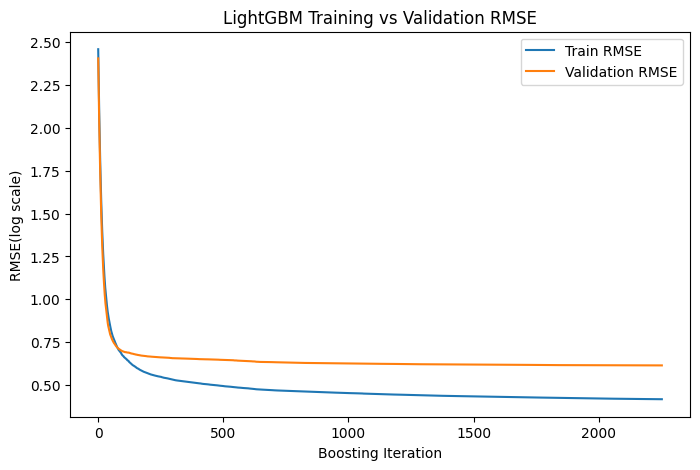

In [28]:
import matplotlib.pyplot as plt

train_rmse = evals_result["train"]["rmse"]
valid_rmse = evals_result["valid"]["rmse"]

plt.figure(figsize=(8,5))
plt.plot(train_rmse, label="Train RMSE")
plt.plot(valid_rmse, label="Validation RMSE")
plt.xlabel("Boosting Iteration")
plt.ylabel("RMSE(log scale)")
plt.title("LightGBM Training vs Validation RMSE")
plt.legend()
plt.show()

# 13. Evaluation and Prediction

In [29]:
# 1. Validate the model
y_pred_log = model.predict(X_val[FEATURES])
y_pred = np.expm1(y_pred_log)
y_pred = np.maximum(y_pred, 0) # Ensure no negative sales

val_rmsle = np.sqrt(mean_squared_log_error(y_val, y_pred))
print(f"Validation RMSLE: {val_rmsle:.5f}")

# 2. Predict on Test set
test_preds_log = model.predict(test[FEATURES])
test['sales'] = np.expm1(test_preds_log)
test['sales'] = np.maximum(test['sales'], 0)

# 3. Create Submission
submission = test[[id, 'sales']]
submission.to_csv('submission.csv', index=False)

Validation RMSLE: 0.61393


# Experimentation Roadmap: Current Concerns & Future Improvements
1. Economic Indicators (Oil Price)
Current Handling: We are currently using pd.NA for missing values to explicitly signal to the model that no oil trading occurred on those days.

Future Experiment: 
- Lagged Economic Impact. A drop in oil prices today may not affect consumer spending immediately. We should test 7-day and 14-day lags to see if consumer behavior reacts to oil price shifts on a delay.
- Evaluating the best imputation method (NaN vs. Forward Fill vs. Moving Average) to handle weekend and market holiday gaps in oil.csv.

2. Holiday & Event Influence
Current Handling: Hierarchical Priority. For days with overlapping holidays (e.g., a Local city holiday on a National holiday), we prioritize the larger scale: National > Regional > Local. This ensures the model sees the most impactful "day-off" event first.

Future Experiment: Overhead Handling: Instead of picking just one locale, we could try binary flags for each level (e.g., is_national, is_local) to see if the additive effect of two holidays creates even higher sales.

3. Time Series Feature Engineering
Current Handling: Basic time features (Year, Month, Day, DayOfWeek) are currently treated as categorical/ordered values to respect the retail cycle.

Future Experiment: Temporal Complexity.
- Lags & Rolling Windows: Implement 16-day lags (to match the test window) and rolling means to capture recent momentum.
- Cyclical Encoding: Transform features like day_of_week and month using Sine/Cosine transforms to represent the circular nature of time (e.g., connecting Sunday back to Monday).

Feature Flagging: You might create a feature called days_since_family_introduction to help the model understand that a category might have lower, more volatile sales in its first few weeks of existence.

In [30]:
# Saving processed-data so that Model Training can be done in another notebook
import os
import pickle

os.makedirs('processed_data', exist_ok=True)

# 1. Save Training Data
X_train.to_pickle('processed_data/X_train.pkl')
y_train.to_pickle('processed_data/y_train.pkl')

# 2. Save Validation Data
X_val.to_pickle('processed_data/X_val.pkl')
y_val.to_pickle('processed_data/y_val.pkl')

# 3. Save Test Data
test.to_pickle('processed_data/test.pkl')

print("All Dataframes Saved")

All Dataframes Saved
